In [66]:
import warnings

warnings.filterwarnings("ignore")

# Libraries to help with reading and manipulating data
import pandas as pd
import numpy as np

# libaries to help with data visualization
import matplotlib.pyplot as plt
import seaborn as sns

# Library to split data
from sklearn.model_selection import train_test_split


# To build linear model for statistical analysis and prediction
import statsmodels.stats.api as sms
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.api as sm
from statsmodels.tools.tools import add_constant

# To get diferent metric scores
from sklearn import metrics
from sklearn.metrics import accuracy_score, roc_curve, confusion_matrix, roc_auc_score

In [67]:
data = pd.read_csv('credit.csv')

In [68]:
data.head()

,checking_balance,months_loan_duration,credit_history,purpose,amount,savings_balance,employment_duration,percent_of_income,years_at_residence,age,other_credit,housing,existing_loans_count,job,dependents,phone,default
0,< 0 DM,6,critical,furniture/appliances,1169,unknown,> 7 years,4,4,67,none,own,2,skilled,1,yes,no
1,1 - 200 DM,48,good,furniture/appliances,5951,< 100 DM,1 - 4 years,2,2,22,none,own,1,skilled,1,no,yes
2,unknown,12,critical,education,2096,< 100 DM,4 - 7 years,2,3,49,none,own,1,unskilled,2,no,no
3,< 0 DM,42,good,furniture/appliances,7882,< 100 DM,4 - 7 years,2,4,45,none,other,1,skilled,2,no,no
4,< 0 DM,24,poor,car,4870,< 100 DM,1 - 4 years,3,4,53,none,other,2,skilled,2,no,yes


In [69]:
data.isnull().sum()

checking_balance        0
months_loan_duration    0
credit_history          0
purpose                 0
amount                  0
savings_balance         0
employment_duration     0
percent_of_income       0
years_at_residence      0
age                     0
other_credit            0
housing                 0
existing_loans_count    0
job                     0
dependents              0
phone                   0
default                 0
dtype: int64

In [70]:
data.isna().sum()

checking_balance        0
months_loan_duration    0
credit_history          0
purpose                 0
amount                  0
savings_balance         0
employment_duration     0
percent_of_income       0
years_at_residence      0
age                     0
other_credit            0
housing                 0
existing_loans_count    0
job                     0
dependents              0
phone                   0
default                 0
dtype: int64

In [71]:
data.isin([0]).sum()

checking_balance        0
months_loan_duration    0
credit_history          0
purpose                 0
amount                  0
savings_balance         0
employment_duration     0
percent_of_income       0
years_at_residence      0
age                     0
other_credit            0
housing                 0
existing_loans_count    0
job                     0
dependents              0
phone                   0
default                 0
dtype: int64

In [72]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype 
---  ------                --------------  ----- 
 0   checking_balance      1000 non-null   object
 1   months_loan_duration  1000 non-null   int64 
 2   credit_history        1000 non-null   object
 3   purpose               1000 non-null   object
 4   amount                1000 non-null   int64 
 5   savings_balance       1000 non-null   object
 6   employment_duration   1000 non-null   object
 7   percent_of_income     1000 non-null   int64 
 8   years_at_residence    1000 non-null   int64 
 9   age                   1000 non-null   int64 
 10  other_credit          1000 non-null   object
 11  housing               1000 non-null   object
 12  existing_loans_count  1000 non-null   int64 
 13  job                   1000 non-null   object
 14  dependents            1000 non-null   int64 
 15  phone                 1000 non-null   o

### Bivariate analysis

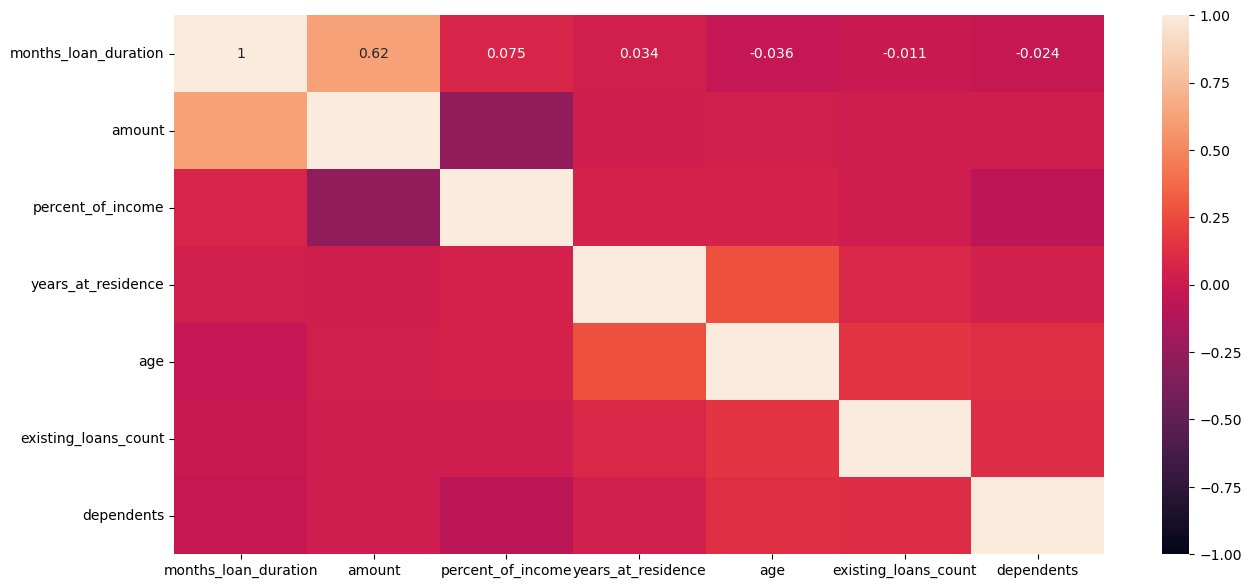

In [73]:
plt.figure(figsize=(15,7))
num_col = data.select_dtypes(include='number')
sns.heatmap(num_col.corr(), vmin=-1, vmax=1, annot=True)
plt.show();

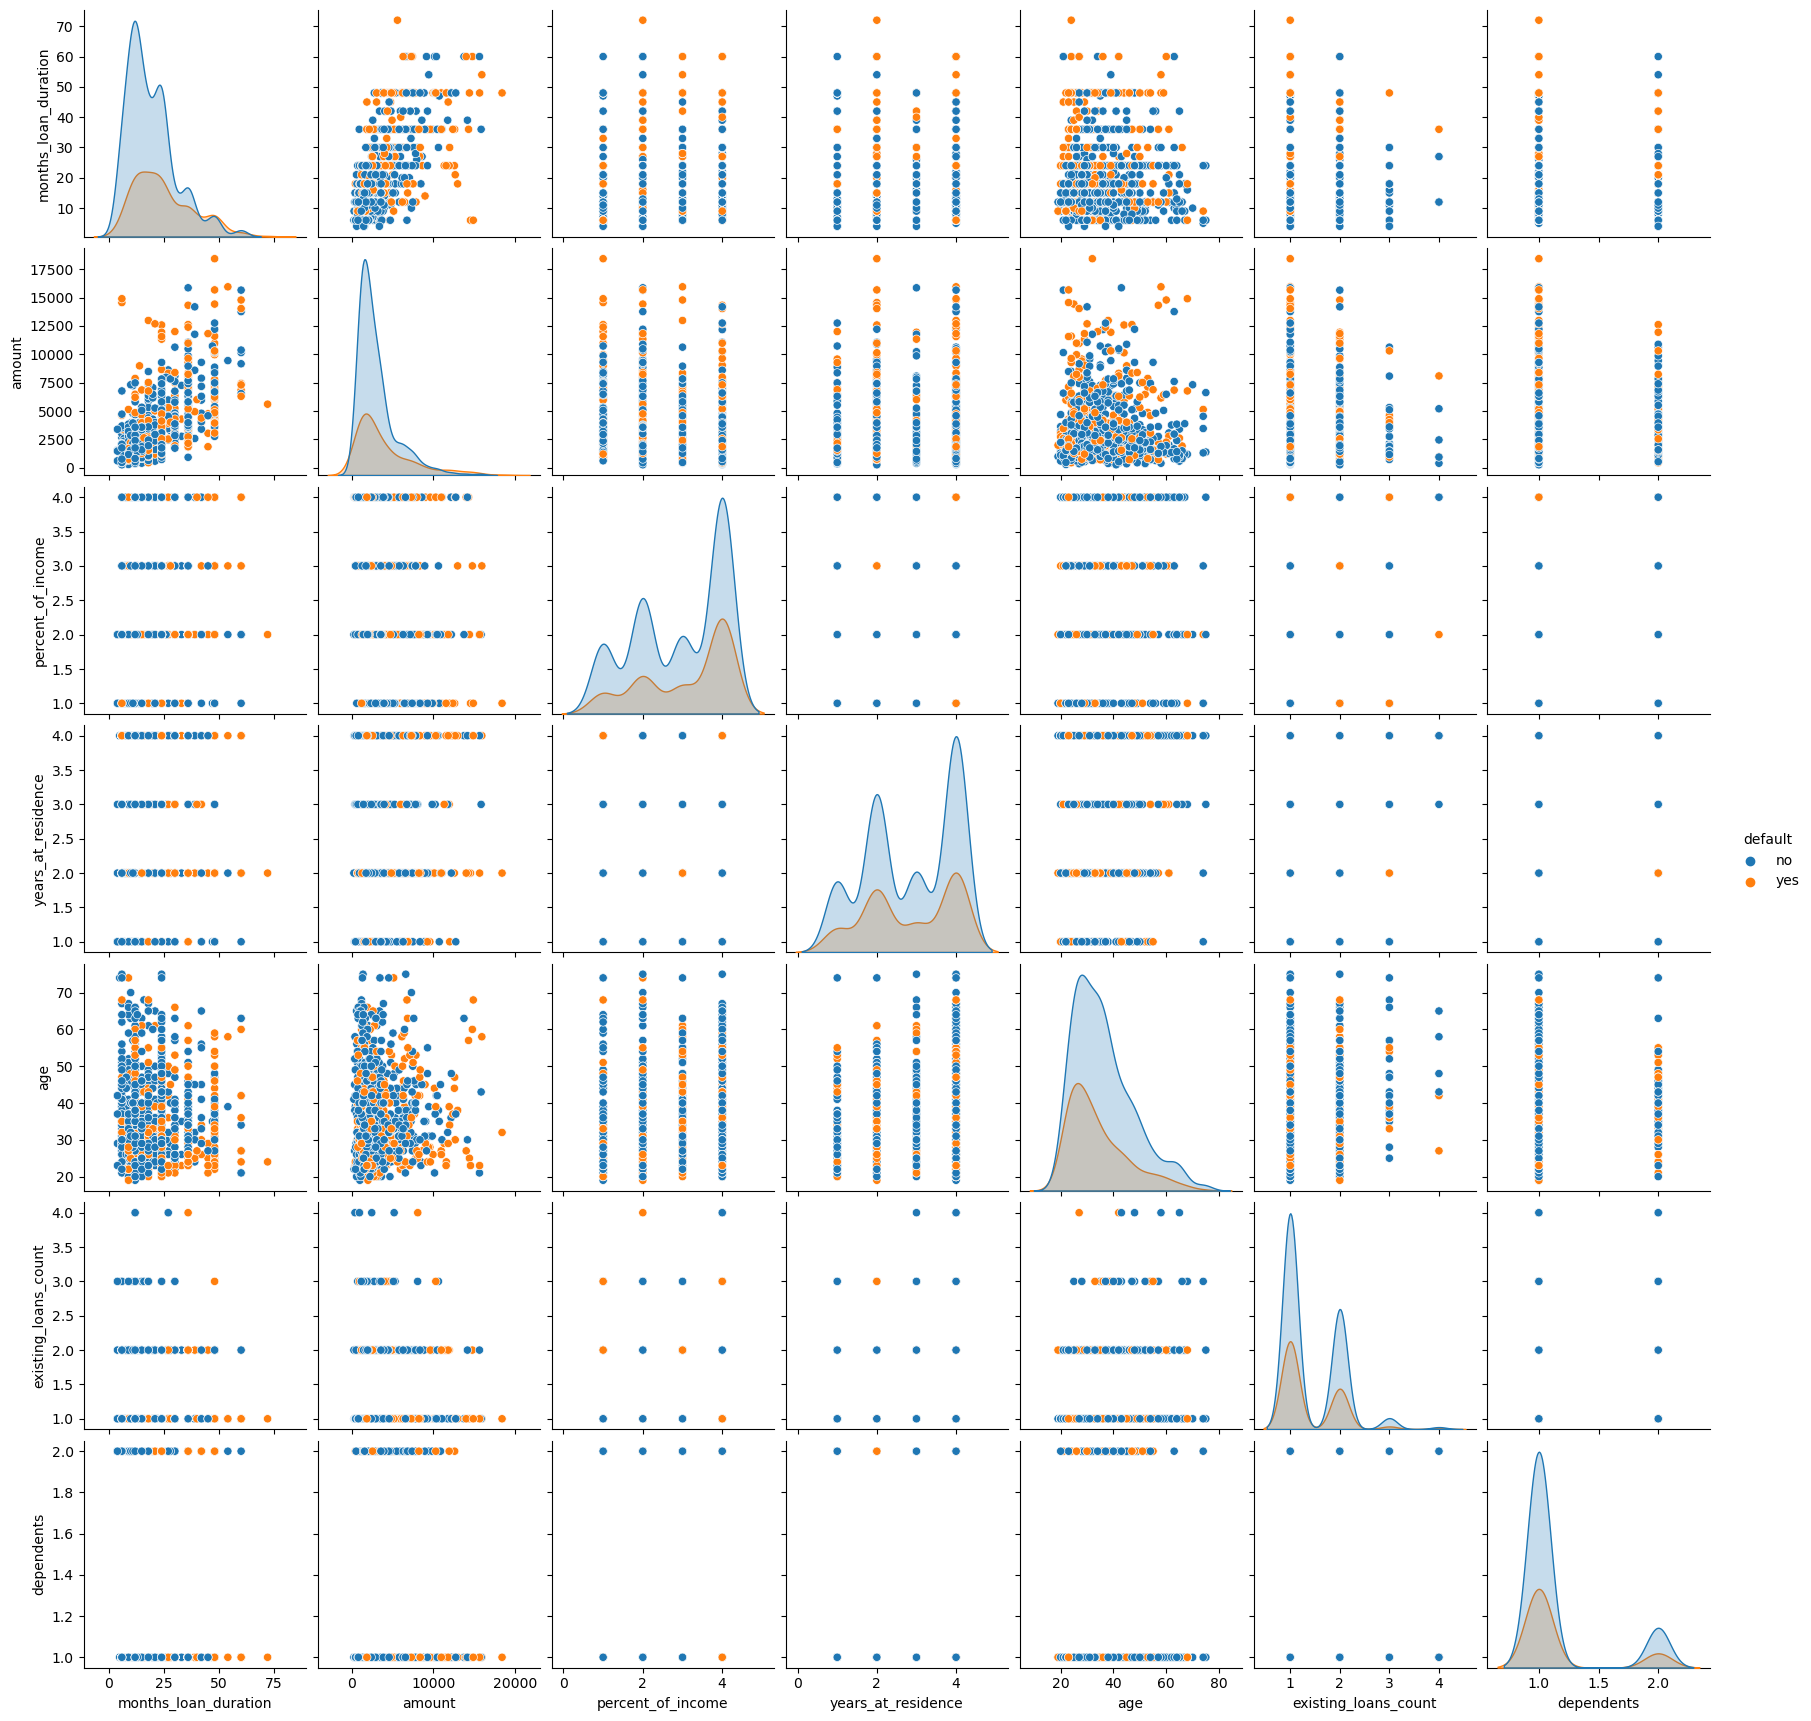

In [74]:
sns.pairplot(data, hue='default')
plt.show();

In [75]:
data['default'].value_counts(1)

default
no     0.7
yes    0.3
Name: proportion, dtype: float64

In [76]:
x = data.drop(['default'],axis=1)
y = data['default']
x = add_constant(x)
x = pd.get_dummies(x, drop_first=True).astype(int)
y = y.map({'no':0, 'yes':1})
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.3, stratify=y, random_state=1)

In [77]:
lg = sm.Logit(y_train, x_train).fit()

Optimization terminated successfully.
         Current function value: 0.477010
         Iterations 7


In [78]:
pred_train = np.round(lg.predict(x_train)>0.5)

In [79]:
print(lg.summary())

                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                  700
Model:                          Logit   Df Residuals:                      664
Method:                           MLE   Df Model:                           35
Date:                Sun, 13 Apr 2025   Pseudo R-squ.:                  0.2191
Time:                        07:11:30   Log-Likelihood:                -333.91
converged:                       True   LL-Null:                       -427.61
Covariance Type:            nonrobust   LLR p-value:                 9.800e-23
                                      coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------------
const                              -3.3474      1.129     -2.966      0.003      -5.559      -1.135
months_loan_duration                0.0269      0.011      2.463    

In [80]:
confusion_matrix(y_train, pred_train)

array([[439,  51],
       [112,  98]], dtype=int64)

In [81]:
accuracy_score(y_train, pred_train)

0.7671428571428571

In [82]:
x_train1 = x_train.drop(columns=['years_at_residence',
                                 'existing_loans_count',
                                 'age',
                                 'dependents',
                                 'checking_balance_> 200 DM',
                                 'purpose_car',
                                 'purpose_car0',
                                 'purpose_furniture/appliances',
                                 'purpose_renovations',
                                 'savings_balance_500 - 1000 DM',
                                 'savings_balance_< 100 DM',
                                 'employment_duration_4 - 7 years',
                                 'employment_duration_> 7 years',
                                 'employment_duration_unemployed',
                                 'other_credit_store',
                                 'housing_own',
                                 'job_skilled',
                                 'job_unemployed',
                                 'job_unskilled'], axis=1)

In [83]:
lg1 = sm.Logit(y_train, x_train1).fit()

Optimization terminated successfully.
         Current function value: 0.486250
         Iterations 7


In [84]:
pred_train1 = np.round(lg1.predict(x_train1))

In [85]:
print(lg1.summary())

                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                  700
Model:                          Logit   Df Residuals:                      683
Method:                           MLE   Df Model:                           16
Date:                Sun, 13 Apr 2025   Pseudo R-squ.:                  0.2040
Time:                        07:11:31   Log-Likelihood:                -340.37
converged:                       True   LL-Null:                       -427.61
Covariance Type:            nonrobust   LLR p-value:                 1.083e-28
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -2.6497      0.474     -5.585      0.000      -3.580      -1.720
months_loan_duration             0.0234      0.010      2.258      0.024     

In [86]:
confusion_matrix(y_train, pred_train1)

array([[437,  53],
       [118,  92]], dtype=int64)

In [87]:
accuracy_score(y_train, pred_train1)

0.7557142857142857

In [88]:
x_train2 = x_train1.drop(columns=['purpose_education'], axis=1)

In [89]:
lg2 = sm.Logit(y_train, x_train2).fit()

Optimization terminated successfully.
         Current function value: 0.488740
         Iterations 7


In [90]:
pred_train2 = np.round(lg2.predict(x_train2))

In [91]:
confusion_matrix(y_train, pred_train2)

array([[436,  54],
       [120,  90]], dtype=int64)

In [92]:
accuracy_score(y_train, pred_train2)

0.7514285714285714

In [93]:
print(lg2.summary())

                           Logit Regression Results                           
Dep. Variable:                default   No. Observations:                  700
Model:                          Logit   Df Residuals:                      684
Method:                           MLE   Df Model:                           15
Date:                Sun, 13 Apr 2025   Pseudo R-squ.:                  0.1999
Time:                        07:11:31   Log-Likelihood:                -342.12
converged:                       True   LL-Null:                       -427.61
Covariance Type:            nonrobust   LLR p-value:                 1.558e-28
                                   coef    std err          z      P>|z|      [0.025      0.975]
------------------------------------------------------------------------------------------------
const                           -2.6239      0.474     -5.538      0.000      -3.553      -1.695
months_loan_duration             0.0225      0.010      2.181      0.029     

### Model performance on test data

In [94]:
odds = np.exp(lg2.params)
pd.DataFrame(odds, x_train2.columns, columns=['odds']).T.round(2)

,const,months_loan_duration,amount,percent_of_income,checking_balance_< 0 DM,checking_balance_unknown,credit_history_good,credit_history_perfect,credit_history_poor,credit_history_very good,savings_balance_> 1000 DM,savings_balance_unknown,employment_duration_< 1 year,other_credit_none,housing_rent,phone_yes
odds,0.07,1.02,1.0,1.43,1.62,0.34,1.88,6.51,2.18,3.35,0.27,0.46,1.86,0.51,1.7,0.65


In [95]:
perc_chang_odds = (np.exp(lg2.params)-1)*100
pd.DataFrame(perc_chang_odds, x_train2.columns, columns=['odds_change%']).T.round(2)

,const,months_loan_duration,amount,percent_of_income,checking_balance_< 0 DM,checking_balance_unknown,credit_history_good,credit_history_perfect,credit_history_poor,credit_history_very good,savings_balance_> 1000 DM,savings_balance_unknown,employment_duration_< 1 year,other_credit_none,housing_rent,phone_yes
odds_change%,-92.75,2.28,0.01,43.21,62.06,-65.73,87.52,550.66,118.45,235.44,-72.65,-54.36,86.24,-49.01,69.95,-34.7


### Final Model Performance

In [96]:
x_test = x_test.drop(columns=['years_at_residence',
                                 'existing_loans_count',
                                 'age',
                                 'dependents',
                                 'checking_balance_> 200 DM',
                                 'purpose_car',
                                 'purpose_car0',
                                 'purpose_furniture/appliances',
                                 'purpose_renovations',
                                 'savings_balance_500 - 1000 DM',
                                 'savings_balance_< 100 DM',
                                 'employment_duration_4 - 7 years',
                                 'employment_duration_> 7 years',
                                 'employment_duration_unemployed',
                                 'other_credit_store',
                                 'housing_own',
                                 'job_skilled',
                                 'job_unemployed',
                                 'job_unskilled',
                                 'purpose_education'], axis=1)

In [98]:
pred_test = np.round(lg2.predict(x_test)>0.5)

In [99]:
accuracy_score(y_test, pred_test)

0.77

In [102]:
confusion_matrix(y_test, pred_test)

array([[187,  23],
       [ 46,  44]], dtype=int64)